## Chapter3 - What to Cover Next?

- Loading and processing data
- Building the model
- Defining the loss function
- Defining the optimizer
- Training and transfer learning
- Deploying the model

STL-10 dataset will be used for demonstration. The images are RGB color with a size of 96*96. The dataset contains 5,000 training images
and 8,000 test images. There are 500 and 800 images per class in the training and test
datasets, respectively.

Labels are:
- Airplane: 0
- Bird: 1
- Car: 2
- Cat: 3
- Deer: 4
- Dog: 5
- Horse: 6
- Monkey: 7
- Ship: 8
- Truck: 9

In [229]:
import torch
from torch import nn,optim
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import Subset, DataLoader
from torchvision import datasets
from torchvision import models
import torchvision.transforms as transforms
from torchvision import utils
from torchsummary import summary

from sklearn.model_selection import StratifiedShuffleSplit

import numpy as np
import collections
import os
import copy

import matplotlib.pyplot as plt
%matplotlib inline

np.random.seed(42)
torch.manual_seed(42)

In [183]:
path2data="./data"

if not os.path.exists(path=path2data):
    os.mkdir(path=path2data)

data_transformer = transforms.Compose([transforms.ToTensor()])
train_ds=datasets.STL10(path2data, split='train', download=True, transform=data_transformer)

print(train_ds.data.shape)

Files already downloaded and verified
(5000, 3, 96, 96)


In [184]:
y_train=[y for _,y in train_ds]
counter_train=collections.Counter(y_train)
print(counter_train)

Counter({1: 500, 5: 500, 6: 500, 3: 500, 9: 500, 7: 500, 4: 500, 8: 500, 0: 500, 2: 500})


In [185]:
test_ds=datasets.STL10(path2data, split='test',download=True,transform=data_transformer)
print(test_ds.data.shape)

Files already downloaded and verified
(8000, 3, 96, 96)


In [186]:
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

indices=list(range(len(test_ds)))
y_test0=[y for _,y in test_ds]

for test_index, val_index in sss.split(indices,y_test0):
    print("test: {}\ntest lenght: {}".format(test_index,len(test_index)))
    print("val: {}\nval lenght: {}".format(val_index,len(val_index)))

test: [ 369 4826 7056 ... 1150 6669  351]
test lenght: 6400
val: [4311 4042 1350 ...  703   97 4926]
val lenght: 1600


In [187]:
val_ds=Subset(test_ds,val_index)
test_ds=Subset(test_ds,test_index)

print("# of Validation: ",len(val_ds))
print("# of Test: ",len(test_ds))


# of Validation:  1600
# of Test:  6400


In [188]:
y_test=[y for _,y in test_ds]
y_val=[y for _,y in val_ds]

counter_test=collections.Counter(y_test)
counter_val=collections.Counter(y_val)

print("Test-Number of images per label: ",counter_test)
print("Val-Number of images per label:  ",counter_val)


Test-Number of images per label:  Counter({2: 640, 6: 640, 1: 640, 8: 640, 0: 640, 9: 640, 4: 640, 5: 640, 7: 640, 3: 640})
Val-Number of images per label:   Counter({8: 160, 5: 160, 9: 160, 3: 160, 0: 160, 1: 160, 6: 160, 2: 160, 7: 160, 4: 160})


In [189]:
def show(img, label=None, color=False):
    npimg=img.numpy()
    
    # Change shape C*H*W to H*W*C 
    npimg_transpose = np.transpose(npimg, (1,2,0))

    if color == False:
        npimg_transpose = npimg_transpose[:,:,0]
        plt.imshow(npimg_transpose, interpolation='nearest', cmap='gray')
    else:
        plt.imshow(npimg_transpose, interpolation='nearest')
    if label is not None:
        plt.title("Label: "+ str(label))
    plt.show()

In [190]:
# Creating sample images in grid
grid_size = 4
random_indice = np.random.randint(0, len(train_ds), grid_size)
print("Randomly selected image indices: ",random_indice)

x_grid_train = [train_ds[i][0] for i in random_indice]
[print(train_ds[i][1]) for i in random_indice]
y_grid_train = [train_ds[i][1] for i in random_indice]

x_grid_train=utils.make_grid(x_grid_train, nrow=4, padding=2)
print(x_grid_train.shape)

Randomly selected image indices:  [ 860 3772 3092  466]
6
9
0
0
torch.Size([3, 100, 394])


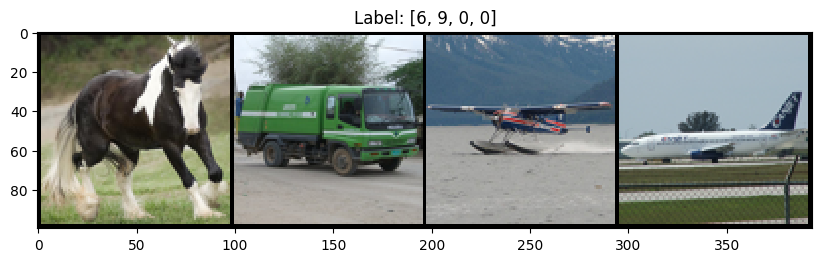

In [191]:
plt.rcParams['figure.figsize'] = (10.0, 5)
show(x_grid_train,y_grid_train, color=True)

In [192]:
meanRGB=[np.mean(x.numpy(),axis=(1,2)) for x,_ in train_ds]
stdRGB=[np.mean(x.numpy(),axis=(1,2)) for x,_ in train_ds]

meanR=np.mean([m[0] for m in meanRGB])
meanG=np.mean([m[1] for m in meanRGB])
meanB=np.mean([m[2] for m in meanRGB])

stdR=np.mean([s[0] for s in stdRGB])
stdG=np.mean([s[1] for s in stdRGB])
stdB=np.mean([s[2] for s in stdRGB])


In [193]:
print("R-Channel mean:{}, std:{}".format(meanR,stdR))
print("G-Channel mean:{}, std:{}".format(meanG,stdG))
print("B-Channel mean:{}, std:{}".format(meanB,stdB))


R-Channel mean:0.44671058654785156, std:0.44671058654785156
G-Channel mean:0.4398098587989807, std:0.4398098587989807
B-Channel mean:0.4066464602947235, std:0.4066464602947235


In [194]:
train_transformer=transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ToTensor(),
    transforms.Normalize([meanR,meanG,meanB], [stdR,stdG,stdB])
])

In [195]:
test_transformer=transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([meanR,meanG,meanB], [stdR,stdG,stdB])
])

In [196]:
train_ds.transform=train_transformer
test_ds.transform=test_transformer

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.0..1.4591385].


Image Indices:  [4426 3444 3171 2919]
torch.Size([3, 100, 394])


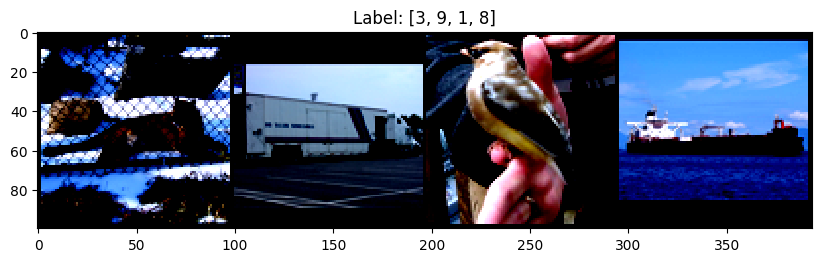

In [197]:
grid_size=4
rnd_inds=np.random.randint(0,len(train_ds),grid_size)
print("Image Indices: ",rnd_inds)

x_grid=[train_ds[i][0] for i in rnd_inds]
y_grid=[train_ds[i][1] for i in rnd_inds]

x_grid=utils.make_grid(x_grid, nrow=4, padding=2)
print(x_grid.shape)

plt.figure(figsize=(10,10))
show(x_grid,y_grid, color=True)


In [198]:
train_dl=DataLoader(train_ds,batch_size=128,shuffle=True)
val_dl=DataLoader(val_ds,batch_size=128,shuffle=False)

for x,y in train_dl:
    print(x.shape)
    print(y.shape)
    break

for x,y in val_dl:
    print(x.shape)
    print(y.shape)
    break

torch.Size([128, 3, 96, 96])
torch.Size([128])
torch.Size([128, 3, 96, 96])
torch.Size([128])


### Building the Models

In [199]:
model_resnet18=models.resnet18(pretrained=False)
print(model_resnet18)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

c:\Users\maa\anaconda3\envs\pytorch-312\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\maa\anaconda3\envs\pytorch-312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [200]:
num_classes=10
num_features=model_resnet18.fc.in_features
model_resnet18.fc=nn.Linear(num_features,num_classes)

device=torch.device("cuda:0")
model_resnet18.to(device=device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [201]:
summary(model_resnet18, input_size=(3,224,224), device=device.type)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]          36,864
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
       BasicBlock-11           [-1, 64, 56, 56]               0
           Conv2d-12           [-1, 64, 56, 56]          36,864
      BatchNorm2d-13           [-1, 64, 56, 56]             128
             ReLU-14           [-1, 64,

In [202]:
for w in model_resnet18.parameters():
    w=w.data.cpu()
    print(w.shape)
    break

torch.Size([64, 3, 7, 7])


In [203]:
min_w=torch.min(w)
w1=(-1/(2*min_w))*w+0.5
print(torch.min(w1).item(),torch.max(w1).item())

0.0 1.0239102840423584


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0239103].


torch.Size([3, 65, 65])


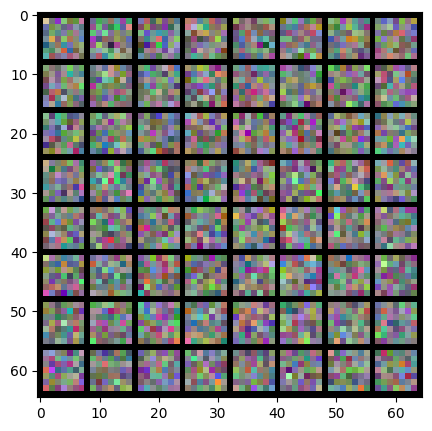

In [204]:
grid_size=len(w1)
x_grid=[w1[i] for i in range(grid_size)]
x_grid=utils.make_grid(x_grid,nrow=8,padding=1)
print(x_grid.shape)

plt.Figure(figsize=(5,5))
show(x_grid,color=True)

In [205]:
resnet18_pretrained = models.resnet18(pretrained=True)
num_classes=10
num_ftrs = resnet18_pretrained.fc.in_features
resnet18_pretrained.fc = nn.Linear(num_ftrs, num_classes)
device = torch.device("cuda:0")
resnet18_pretrained.to(device)

c:\Users\maa\anaconda3\envs\pytorch-312\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1026189].


torch.Size([64, 3, 7, 7])
0.0 1.102618932723999
torch.Size([3, 65, 65])


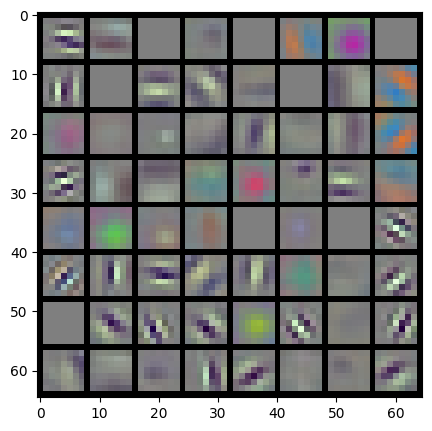

In [207]:
for w in resnet18_pretrained.parameters():
    w=w.data.cpu()
    print(w.shape)
    break

min_w=torch.min(w)
w1=(-1/(2*min_w))*w+0.5
print(torch.min(w1).item(),torch.max(w1).item())

grid_size=len(w1)
x_grid=[w1[i] for i in range(grid_size)]
x_grid=utils.make_grid(x_grid,nrow=8,padding=1)
print(x_grid.shape)

plt.Figure(figsize=(5,5))
show(x_grid,color=True)


### Defining Loss Function

In [ ]:
loss_func=nn.CrossEntropyLoss(reduction="sum")

torch.Size([4, 5])


In [209]:
torch.manual_seed(0)

n,c=4,5

y=torch.randn(n,c,requires_grad=True)
print(y.shape)

loss_func=nn.CrossEntropyLoss(reduction="sum")
target=(torch.randint(c,size=(n,)))
print(target.shape)

loss=loss_func(y,target)
print(loss.item())

torch.Size([4, 5])
torch.Size([4])
7.312585830688477


In [210]:
loss.backward()

print(y.data)

tensor([[-1.1258, -1.1524, -0.2506, -0.4339,  0.5988],
        [-1.5551, -0.3414,  1.8530,  0.4681, -0.1577],
        [ 1.4437,  0.2660,  1.3894,  1.5863,  0.9463],
        [-0.8437,  0.9318,  1.2590,  2.0050,  0.0537]])


### Defining Optimizer

In [218]:
opt=optim.Adam(model_resnet18.parameters(),lr=1e-4)

In [219]:
def get_lr(opt):
    for param_group in opt.param_groups:
        return param_group['lr']
    
current_lr=get_lr(opt)

print("Current learning rate: ", current_lr)

Current learning rate:  0.0001


In [220]:
lr_scheduler=CosineAnnealingLR(opt,T_max=2,eta_min=1e-5)

for i in range(10):
    lr_scheduler.step()
    print("epoch %s, lr: %.1e" %(i,get_lr(opt)))

epoch 0, lr: 5.5e-05
epoch 1, lr: 1.0e-05
epoch 2, lr: 5.5e-05
epoch 3, lr: 1.0e-04
epoch 4, lr: 5.5e-05
epoch 5, lr: 1.0e-05
epoch 6, lr: 5.5e-05
epoch 7, lr: 1.0e-04
epoch 8, lr: 5.5e-05
epoch 9, lr: 1.0e-05


epoch 0, lr: 5.5e-05
epoch 1, lr: 1.0e-04
epoch 2, lr: 5.5e-05
epoch 3, lr: 1.0e-05
epoch 4, lr: 5.5e-05
epoch 5, lr: 1.0e-04
epoch 6, lr: 5.5e-05
epoch 7, lr: 1.0e-05
epoch 8, lr: 5.5e-05
epoch 9, lr: 1.0e-04


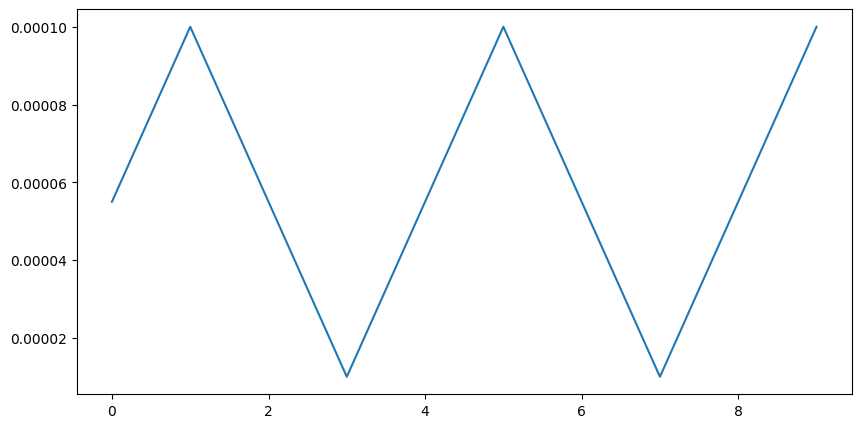

In [225]:
lrs=[]
for i in range(10):
    lr_scheduler.step()
    lr=get_lr(opt)
    print("epoch %s, lr: %.1e" %(i,lr))
    lrs.append(lr)

plt.plot(lrs)
plt.show()

### Training and Transfer Learning

#### Helper Functions

In [ ]:
# Helper-1. Count the number of correct predictions
def metrics_batch(output, target):
    pred = output.argmax(dim=1, keepdim=True)
    corrects=pred.eq(target.view_as(pred)).sum().item()
    return corrects

In [222]:
# Helper-2. Compute the loss value per batch of data
def loss_batch(loss_func, output, target, opt=None):
    loss = loss_func(output, target)
    metric_b = metrics_batch(output,target)
    if opt is not None:
        opt.zero_grad()
        loss.backward()
        opt.step()
    return loss.item(), metric_b

In [236]:
# Helper-3 Compute the loss value and the performance metric for the entire dataset or an epoch
def loss_epoch(model,loss_func,dataset_dl,sanity_check=False,opt=None):
    running_loss=0.0
    running_metric=0.0
    len_data=len(dataset_dl.dataset)

    device=torch.device("cuda:0")
    model.to(device)

    loader = DataLoader(
        dataset_dl.dataset,
        batch_size=512,
        shuffle=False,
        pin_memory=True
    )

    for xb, yb in loader:
        # move batch to device
        xb=xb.to(device,non_blocking=True)
        yb=yb.to(device,non_blocking=True)

        # get model output
        output=model(xb)

        # get loss per batch
        loss_b,metric_b=loss_batch(loss_func, output, yb, opt)

        # update running loss
        running_loss+=loss_b

        # update running metric
        if metric_b is not None:
            running_metric+=metric_b

        # break the loop in case of sanity check
        if sanity_check is True:
            break
    
    loss=running_loss/float(len_data)
    metric=running_metric/float(len_data)
    return loss, metric

In [237]:
def train_val(model, params):
    # extract model parameters
    num_epochs=params["num_epochs"]
    loss_func=params["loss_func"]
    opt=params["optimizer"]
    train_dl=params["train_dl"]
    val_dl=params["val_dl"]
    sanity_check=params["sanity_check"]
    lr_scheduler=params["lr_scheduler"]
    path2weights=params["path2weights"]
    
    # history of loss values in each epoch
    loss_history={
        "train": [],
        "val": [],
    }
    
    # histroy of metric values in each epoch
    metric_history={
        "train": [],
        "val": [],
    }
    
    # a deep copy of weights for the best performing model
    best_model_wts = copy.deepcopy(model.state_dict())
    
    # initialize best loss to a large value
    best_loss=float('inf')
    
    # main loop
    for epoch in range(num_epochs):
        
        # get current learning rate
        current_lr=get_lr(opt)
        print('Epoch {}/{}, current lr={}'.format(epoch, num_epochs - 1, current_lr))
        
        # train model on training dataset
        model.train()
        train_loss, train_metric=loss_epoch(model,loss_func,train_dl,sanity_check,opt)

        # collect loss and metric for training dataset
        loss_history["train"].append(train_loss)
        metric_history["train"].append(train_metric)
        
        # evaluate model on validation dataset    
        model.eval()
        with torch.no_grad():
            val_loss, val_metric=loss_epoch(model,loss_func,val_dl,sanity_check)
        
       
        # store best model
        if val_loss < best_loss:
            best_loss = val_loss
            best_model_wts = copy.deepcopy(model.state_dict())
            
            # store weights into a local file
            torch.save(model.state_dict(), path2weights)
            print("Copied best model weights!")
        
        # collect loss and metric for validation dataset
        loss_history["val"].append(val_loss)
        metric_history["val"].append(val_metric)
        
        # learning rate schedule
        lr_scheduler.step()

        print("train loss: %.6f, dev loss: %.6f, accuracy: %.2f" %(train_loss,val_loss,100*val_metric))
        print("-"*10) 

    # load best model weights
    model.load_state_dict(best_model_wts)
        
    return model, loss_history, metric_history

#### Train with Random Init Weights

In [239]:
import copy

loss_func = nn.CrossEntropyLoss(reduction="sum")
opt = optim.Adam(model_resnet18.parameters(), lr=1e-4)
lr_scheduler = CosineAnnealingLR(opt,T_max=5,eta_min=1e-6)

params_train={
 "num_epochs": 3,
 "optimizer": opt,
 "loss_func": loss_func,
 "train_dl": train_dl,
 "val_dl": val_dl,
 "sanity_check": False,
 "lr_scheduler": lr_scheduler,
 "path2weights": "./models/resnet18.pt",
}

# train and validate the model
model_resnet18,loss_hist,metric_hist=train_val(model_resnet18,params_train)

Epoch 0/2, current lr=0.0001
Copied best model weights!
train loss: 1.726434, dev loss: 4.673543, accuracy: 10.00
----------
Epoch 1/2, current lr=9.05463412215599e-05
Copied best model weights!
train loss: 1.522379, dev loss: 3.083109, accuracy: 12.38
----------
Epoch 2/2, current lr=6.57963412215599e-05
Copied best model weights!
train loss: 1.415451, dev loss: 2.685135, accuracy: 19.88
----------


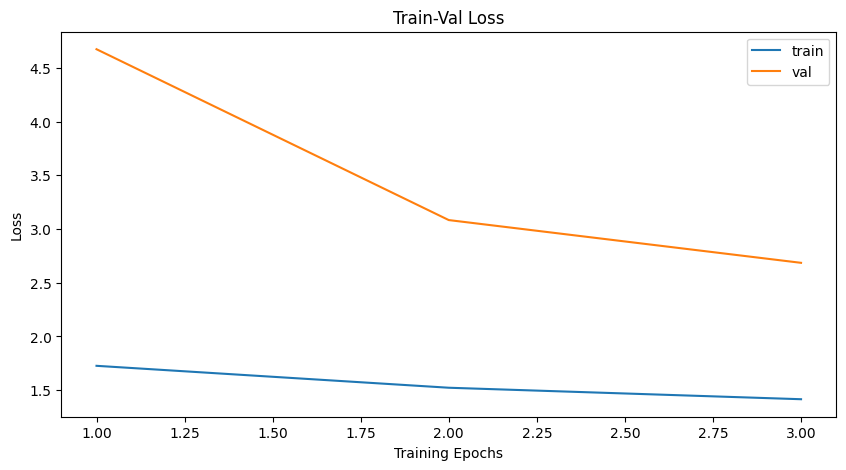

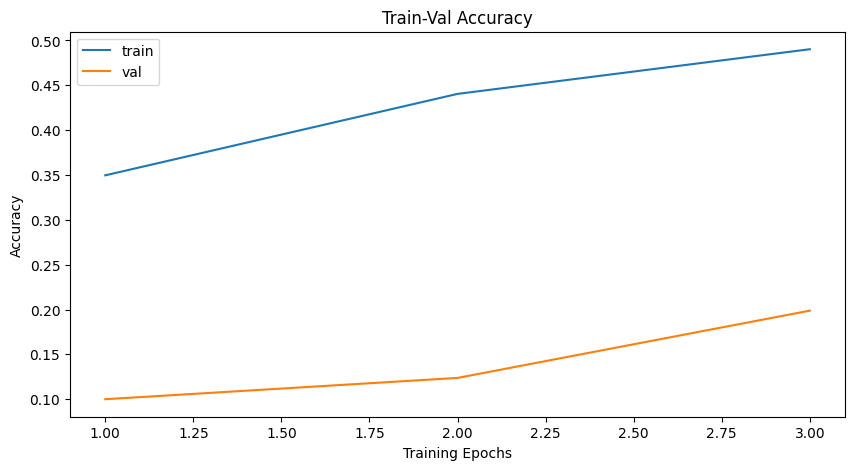

In [240]:
# Train-Validation Progress
num_epochs=params_train["num_epochs"]

# plot loss progress
plt.title("Train-Val Loss")
plt.plot(range(1,num_epochs+1),loss_hist["train"],label="train")
plt.plot(range(1,num_epochs+1),loss_hist["val"],label="val")
plt.ylabel("Loss")
plt.xlabel("Training Epochs")
plt.legend()
plt.show()

# plot accuracy progress
plt.title("Train-Val Accuracy")
plt.plot(range(1,num_epochs+1),metric_hist["train"],label="train")
plt.plot(range(1,num_epochs+1),metric_hist["val"],label="val")
plt.ylabel("Accuracy")
plt.xlabel("Training Epochs")
plt.legend()
plt.show()

#### Train with Pre-Trained Weights

In [243]:
loss_func = nn.CrossEntropyLoss(reduction="sum")
opt = optim.Adam(resnet18_pretrained.parameters(), lr=1e-4)
lr_scheduler = CosineAnnealingLR(opt,T_max=5,eta_min=1e-6)

params_train={
 "num_epochs": 10,
 "optimizer": opt,
 "loss_func": loss_func,
 "train_dl": train_dl,
 "val_dl": val_dl,
 "sanity_check": False,
 "lr_scheduler": lr_scheduler,
 "path2weights": "./models/resnet18_pretrained.pt",
}

# train and validate the model
resnet18_pretrained,loss_hist,metric_hist=train_val(resnet18_pretrained,params_train)

Epoch 0/9, current lr=0.0001
Copied best model weights!
train loss: 0.524584, dev loss: 0.923045, accuracy: 66.69
----------
Epoch 1/9, current lr=9.05463412215599e-05
Copied best model weights!
train loss: 0.353279, dev loss: 0.874514, accuracy: 68.94
----------
Epoch 2/9, current lr=6.57963412215599e-05
train loss: 0.254123, dev loss: 0.921487, accuracy: 67.44
----------
Epoch 3/9, current lr=3.52036587784401e-05
train loss: 0.198505, dev loss: 0.952765, accuracy: 66.19
----------
Epoch 4/9, current lr=1.0453658778440105e-05
train loss: 0.178790, dev loss: 0.953682, accuracy: 66.94
----------
Epoch 5/9, current lr=1e-06
train loss: 0.178599, dev loss: 0.949899, accuracy: 66.88
----------
Epoch 6/9, current lr=1.0453658778440102e-05
train loss: 0.175004, dev loss: 0.939968, accuracy: 67.19
----------
Epoch 7/9, current lr=3.520365877844009e-05
train loss: 0.155256, dev loss: 0.933255, accuracy: 67.69
----------
Epoch 8/9, current lr=6.579634122155988e-05
train loss: 0.131710, dev loss

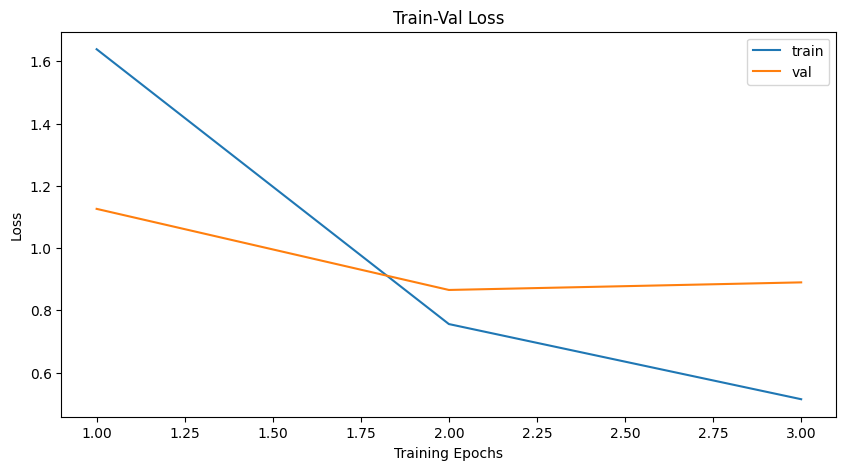

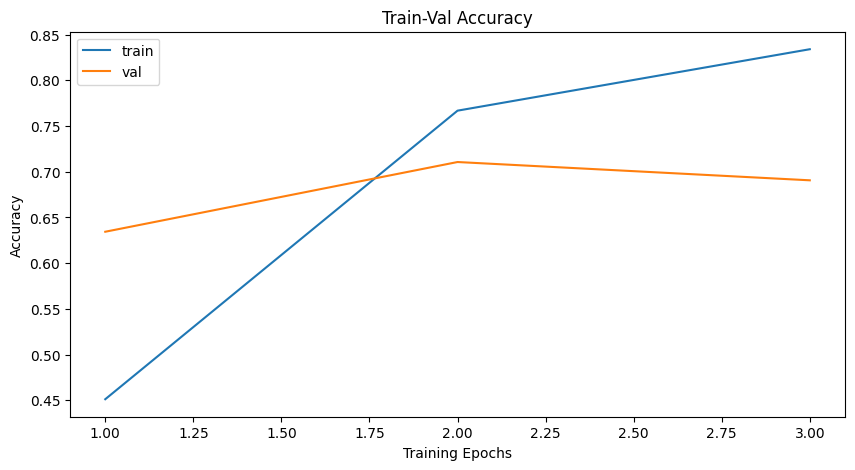

In [242]:
# Train-Validation Progress
num_epochs=params_train["num_epochs"]

# plot loss progress
plt.title("Train-Val Loss")
plt.plot(range(1,num_epochs+1),loss_hist["train"],label="train")
plt.plot(range(1,num_epochs+1),loss_hist["val"],label="val")
plt.ylabel("Loss")
plt.xlabel("Training Epochs")
plt.legend()
plt.show()

# plot accuracy progress
plt.title("Train-Val Accuracy")
plt.plot(range(1,num_epochs+1),metric_hist["train"],label="train")
plt.plot(range(1,num_epochs+1),metric_hist["val"],label="val")
plt.ylabel("Accuracy")
plt.xlabel("Training Epochs")
plt.legend()
plt.show()